```28/07/2025 - Gabriel A. Amici```

# Implementando classes para a biblioteca ```emerald```

### Objetivos:
- Compactar código
- Reutilizar rotinas similares
- Facilitar uso da biblioteca

### Classes base:
- ```Potential```
- ```Field```
- ```Particle```
- ```System```

In [2]:
import numpy as np
import warnings

In [3]:


class Potential:
    """
    Base class for 1D potentials, responsible for calculating the potential 
    and its derivatives, as well as the classical return points.
    """

    def __init__(self, *args, **kwargs):
        self.name    = None
        self.acronym = None

    def __call__(self, positions):
        return self.value(positions)
    
    def value(self, positions):
        """
        Potential evaluated at a range of positions

        Parameters
        ----------
        positions : array-like
            Array of positions at which to evaluate the potential

        Returns
        -------
        potential_values : array-like
            Array of potential values corresponding to the input positions
        """
        r = np.asarray(positions)
        pass
    
    def first_derivative(self, positions):
        """
        1st derivative of the potential evaluated for a range of positions

        Parameters
        ----------
        positions : array-like
            Array of positions at which to evaluate the derivative

        Returns
        -------
        first_derivative_values : array-like
            Array of first derivative values corresponding to the input positions
        """
        r = np.asarray(positions)
        pass
    
    def second_derivative(self, positions):
        """
        2nd derivative of the potential evaluated for a range of positions

        Parameters
        ----------
        positions : array-like
            Array of positions at which to evaluate the second derivative

        Returns
        -------
        second_derivative_values : array-like
            Array of second derivative values corresponding to the input positions
        """
        r = np.asarray(positions)
        pass
    
    def return_points(self):
        """Classical return points of the potential"""
        pass

A partir da classe base é possível implementar potenciais como classes herdadas:

In [4]:
class MorseSoftCoulomb(Potential):
    """
    Morse-soft-Coulomb potential (MsC) is a 1D soft potential with a Morse 
    barrier at the origin. The parameter `alpha` controls the well depth and
    barrier hardness.
    """
    
    def __init__(self, alpha):
        super().__init__()
        self.name       = "Morse-soft-Coulomb"
        self.acronym    = "MsC"
        self.alpha      = alpha
        self.well_depth = 1 / alpha
        self.beta       = 1 / (alpha * np.sqrt(2))
    
    def value(self, positions):
        """
        Evaluates the Morse-soft-Coulomb potential at every point in 
        `positions`.
        """
        r = np.asarray(positions)
        
        coulomb = -1 / np.sqrt(r**2 + self.alpha**2)
        morse   = self.well_depth * (np.exp(-2 * self.beta * r) - 2 * np.exp(-self.beta * r))
        
        return np.where(r > 0, coulomb, morse)
    
    def first_derivative(self, positions):
        """
        Evaluates the first derivative of the MsC potential at the spacial points
        in `position-array`
        """
        r = np.asarray(positions)
        
        coulomb = r*(r**2 + self.alpha**2)**(-3/2)
        morse   = 2*self.well_depth*self.beta*np.exp( -2*self.beta*r)*( np.exp( self.beta*r ) - 1 )
        
        return np.where(r > 0, coulomb, morse)
    
    def second_derivative(self, positions):
        """
        Evaluates the second derivative of the MsC potential at the spacial points
        in `position-array`
        """
        r = np.asarray(positions)
        
        coulomb = (r**2 + self.alpha**2)**(-3/2) - 3*r**2*(r**2 + self.alpha**2)**(-5/2)
        morse = 4*self.well_depth*self.beta**2*np.exp( -2*self.beta*r )*( np.exp( self.beta*r ) - 0.5 )
        
        return np.where(r > 0, coulomb, morse)
    
    def return_points(self, energy: float = 0.):
        """
        Calculates the return points of the MsC potential at a given energy, 
        defaults to `(None, None)`.  
        """
        if energy < -self.well_depth:
            warnings.warn(f"Energy must be greater than the well depth ({-self.well_depth})")
            return (None, None) 

        rm = -self.alpha*np.sqrt(2)*np.log( np.sqrt( self.alpha*energy + 1 ) + 1 )
        rM = np.sqrt( 1/(energy**2) - self.alpha**2 )
        
        if energy >= 0:
            return (rm, None)
        else:
            return (rm, rM)


In [5]:
msc = MorseSoftCoulomb(alpha=0.5)

In [6]:
msc(1)

array(-0.89442719)

In [7]:
import matplotlib.pyplot as plt

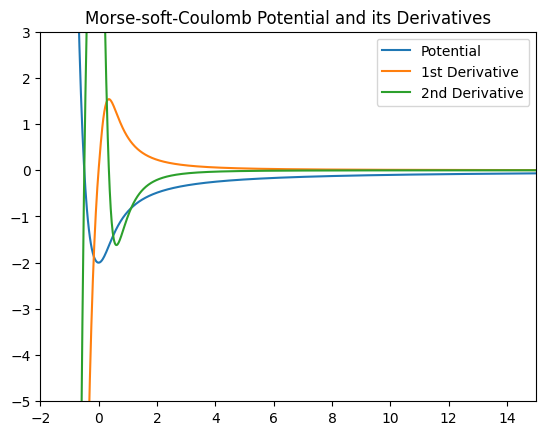

In [8]:
r = np.linspace(-2, 15, 1000)

plt.title(f"{msc.name} Potential and its Derivatives")
plt.plot(r, msc.value(r), label='Potential')
plt.plot(r, msc.first_derivative(r), label='1st Derivative')
plt.plot(r, msc.second_derivative(r), label='2nd Derivative')
plt.xlim(-2, 15)
plt.ylim(-5, 3)
plt.legend()
plt.show()

### `Field` class

We define a field as a callable that returns the (electric) field value at time $t$. We may write a generic field object which interpolates
an array of times with an array of field values, later implementing specific fields with their corresponding parameters and analytical 
expressions:

In [9]:
class Field:
    """
    Basic (electric) field class, given an array of field values and times, calling it results in an
    evaluation of the field (interpolated when necessary) at the specified time
    """

    def __init__(self):
        pass
    
    def __call__(self, times):
        return self.value(times)

    def value(self, times):
        """
        Evaluate the field at `times`
        """

In [10]:
class InterpolatedField(Field):

    def __init__(self, field_times: np.ndarray, field_vals: np.ndarray):
        super().__init__()
        if len(field_times) != len(field_vals):
            raise Warning(f"Time array and field array must be of same size! "
                          f"{len(field_times)} ≠ {len(field_vals)}")

        self.field_times = field_times
        self.field_vals  = field_vals

    def value(self, times):
        """
        Evaluate the field at `times` interpolating `field_vals` and `field_times`
        """
        t = np.asarray(times)
        return np.interp(t, self.field_times, self.field_vals)

In [11]:
class SinusoidField(Field):

    def __init__(self, amplitude: float, ang_frequency: float, phase: float):
        super().__init__()
        self.amplitude     = amplitude
        self.ang_frequency = ang_frequency
        self.phase         = phase

    def value(self, times):
        return self.amplitude*np.sin( self.ang_frequency*times + self.phase )

In [12]:
t = np.linspace(-3, 3, 30)
F = np.sin(t)

In [13]:
fld = InterpolatedField(t, F)

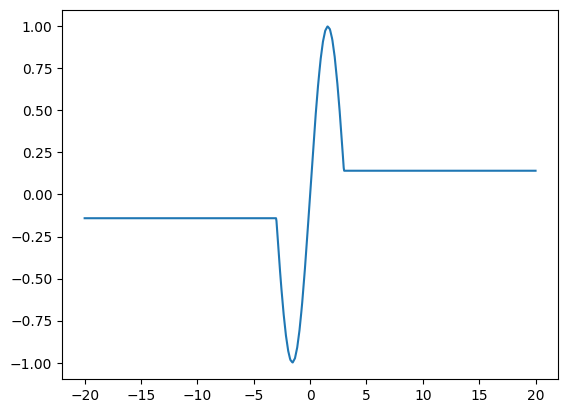

In [14]:
times = np.linspace(-20, 20, 1000)

plt.plot(times, fld(times))

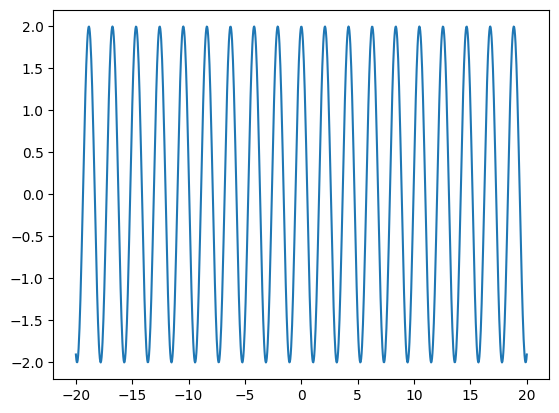

In [15]:
F2 = SinusoidField(2, 3, np.pi/2)

plt.plot(times, F2(times))

## 3. Particle (electron)

In [92]:
class Dynamics:

    def __init__(self, potential: Potential,
                 field: Field = None):

        self.potential = potential
        self.field     = field

    def dstate(self, time: float = 0.0, state: np.ndarray = None):
        r, p = state[0], state[1]
        
        f1 = p
        f2 = -self.potential.first_derivative(r) - self.field(time)
        
        return np.stack([f1, f2], axis=-1)

class StaticDynamics(Dynamics):

    def __init__(self, potential):
        super().__init__(potential)

    def dstate(self, time: float = 0.0, state: np.ndarray = None):
        r, p = state[0], state[1]

        f1 = p
        f2 = -self.potential.first_derivative(r)
        
        return np.stack([f1, f2], axis=-1)

In [93]:
class Trajectory:
    def __init__(self, time, states, potential):
        self.time, self.states, self.potential = time, states, potential

    def energy(self):
        r, p = self.states[..., 0], self.states[..., 1]
        return p**2 / 2 + self.potential.value(r)   # vectorized, works for N=1 or N=many


In [94]:
from abc import ABC, abstractmethod


class Integrator(ABC):

    @abstractmethod
    def propagate(self, state0, dynamics, t_span, t_eval): ...


class FixedStepIntegrator(Integrator):
    """Shared substep/output-grid logic. Subclasses only supply the one-step formula."""

    def __init__(self, dt: float):
        self.dt = dt

    def _step(self, dynamics, t, state, h):
        """
        Naivest integrator: forward Euler's method
        """

        return state + dynamics.dstate(t, state) * h


    def propagate(self, dynamics, state0, t_span, t_eval=None):
        t0, tf = t_span
        if t_eval is None:
            t_eval = np.arange(t0, tf, self.dt)      # library-wide default: dt's own grid

        state0 = np.asarray(state0, dtype=float)
        states = np.empty((len(t_eval), *state0.shape))
        t, state = t0, state0

        print(state)

        for j, t_target in enumerate(t_eval):
            while t < t_target:
                h = min(self.dt, t_target - t)         # only the last substep shrinks
                state = self._step(dynamics, t, state, h)
                t += h
            states[j] = state

        return Trajectory(np.asarray(t_eval), states, dynamics.potential)


class RK4Integrator(FixedStepIntegrator):

    def __init__(self, dt = 1.e-4):
        super().__init__(dt)

    def _step(self, dynamics, t, state, h):
        """
        Order 4 Runge-Kutta method for solving differencial equation systems
        """

        k1 = dynamics.dstate(t,         state)
        k2 = dynamics.dstate(t + 0.5*h, state + 0.5*h*k1)
        k3 = dynamics.dstate(t + 0.5*h, state + 0.5*h*k2)
        k4 = dynamics.dstate(t + h,     state + h*k3)
        return state + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

from scipy.integrate import solve_ivp

class ScipyIntegrator(Integrator):
    def __init__(self, method: str = "RK45", **options):
        self.method, self.options = method, options

    def propagate(self, dynamics, state0, t_span, t_eval=None):
        sol = solve_ivp(dynamics.dstate, t_span, state0,
                         method=self.method, t_eval=t_eval, **self.options)
        return Trajectory(sol.t, sol.y.T, dynamics.potential)

In [89]:
field = SinusoidField(amplitude=0.4, ang_frequency=0.8, phase=0.0)

In [95]:
msc = MorseSoftCoulomb(alpha=0.5)
dyn = Dynamics(msc, field)

prop1 = RK4Integrator(dt=1.e-4)

traj1 = prop1.propagate(dyn, state0=np.array([1.0, 0.0]), t_span=(0, 100), t_eval=np.linspace(0, 100, 1000))

[1. 0.]


KeyboardInterrupt: 

In [74]:
prop3 = FixedStepIntegrator(dt=1.e-4)

traj3 = prop3.propagate(dyn, state0=np.array([1.0, 0.0]), t_span=(0, 100), t_eval=np.linspace(0, 100, 1000))

[1. 0.]


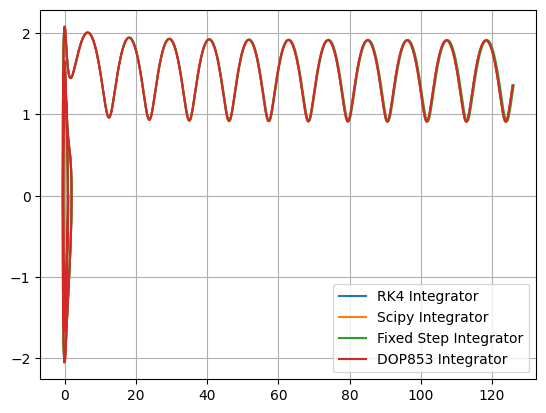

In [82]:
plt.plot(traj1.states[:, 0], traj1.states[:, 1], label='RK4 Integrator')
plt.plot(traj2.states[:, 0], traj2.states[:, 1], label='Scipy Integrator')
plt.plot(traj3.states[:, 0], traj3.states[:, 1], label='Fixed Step Integrator')
plt.plot(traj4.states[:, 0], traj4.states[:, 1], label='DOP853 Integrator')

plt.legend()
plt.grid()
# plt.xlim(10, 16)

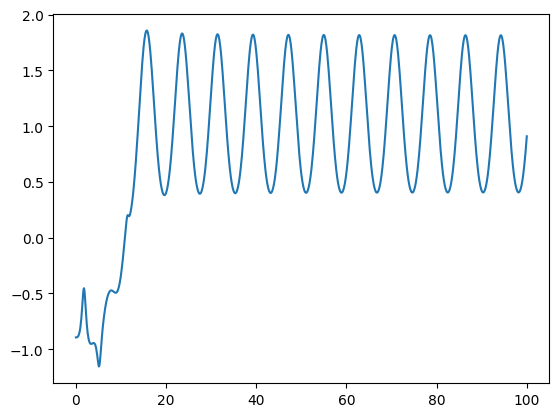

In [83]:
plt.plot(traj1.time, traj1.energy())

In [96]:
state0 = np.random.rand(10, 2)

traj_test = prop1.propagate(dyn, state0=state0, t_span=(0, 10), t_eval=np.linspace(0, 10, 1000))

[[0.7083183  0.92696462]
 [0.01519105 0.79255385]
 [0.65927847 0.80244149]
 [0.88903735 0.52681245]
 [0.37650406 0.20094609]
 [0.12510848 0.682019  ]
 [0.31604911 0.11802025]
 [0.30488429 0.39283264]
 [0.59866059 0.5894871 ]
 [0.89097362 0.56797381]]


ValueError: operands could not be broadcast together with shapes (10,2) (2,2) 

In [75]:
prop2 = ScipyIntegrator(rtol=1.e-6, atol=1.e-9, method="RK45")

traj2 = prop2.propagate(dyn, state0=np.array([1.0, 0.0]), t_span=(0, 100), t_eval=np.linspace(0, 100, 1000))

In [76]:
prop4 = ScipyIntegrator(method="DOP853",
                   rtol=1e-10, atol=1e-12)

traj4 = prop4.propagate(dyn, state0=np.array([1.0, 0.0]), t_span=(0, 100), t_eval=np.linspace(0, 100, 1000))

In [ ]:
class ClassicalParticle:

    def __init__(self, potential: Potential, dynamics: Dynamics,
                 position: float, momentum: float):
        self.potential   = potential
        self.dynamics    = dynamics
        self.position    = position
        self.momentum    = momentum
        self.state       = np.array([position, momentum])

    def hamiltonian(self, position: float, momentum: float) -> float:
        """
        Hamiltonian of the particle at a given position and momentum
        """
        return (momentum**2)/2 + self.potential.value(position)

    def propagate(self, integrator: Integrator, time: float = 0.0):
        """
        Propagate the particle's state using the specified integrator
        """
        self.state = integrator.step(time, self.state)
        self.position, self.momentum = self.state

    def trajectory(self, integrator: Integrator, times: np.ndarray):
        """
        Propagate the particle's state over a range of times and return the trajectory
        """
        trajectory = np.zeros((len(times), 2))
        for i, t in enumerate(times):
            self.propagate(integrator, t)
            trajectory[i] = self.state.copy()
        return trajectory



In [ ]:
msc = MorseSoftCoulomb(alpha=0.1)
dynamics = StaticDynamics(potential=msc)
electron = ClassicalParticle(potential=msc, dynamics=dynamics, position=1.0, momentum=0.0)
integrator = RK4Integrator(dynamics=dynamics, dt=1.e-3)

electron.state
plt.plot(*electron.trajectory(integrator, np.linspace(0, 100, 10000)).T)
